In [1]:
import os
import xarray as xr
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from shared_read_HBR import *
from matplotlib import rcParams
from matplotlib.patches import Patch

#site = 'UC_Davis'
#prefix = '20250811'
#suffix = ''
#site = 'HBR'
#prefix = '20250913'
#suffix = ''
#prefix = '20250730'
#suffix = 'phi0.2_div10000'
site = 'UIEF'
prefix = '20250925'
suffix = 'obsForc'
#prefix = '20251001'
#suffix = 'obsForc'
#suffix = 'appCtrl'

rcParams['font.size'] = 16
rcParams['axes.titlesize'] = 16

elm_thickness = np.diff(np.array([0, 1.75, 4.51, 9.06, 16.55, 28.91, 49.29, 82.89, 138.28]))

In [2]:
flist = [os.path.join(os.environ['E3SM_ROOT'], 'output', 
                        f'{prefix}_{site}_ICB20TRCNPRDCTCBC_{suffix}erw', 'run', 
                        f'{prefix}_{site}_ICB20TRCNPRDCTCBC_{suffix}erw.elm.h1.{yy}-01-01-00000.nc') \
            #for yy in range(1850,1872)]
            #for yy in range(1863, 1900)]
            #for yy in range(1876, 1883)]
            #for yy in range(1920, 1950)]
            #for yy in range(2010, 2023)]
            for yy in range(1850, 2023, 10)]

if site == 'UIEF':
    datestr = '1862-12-31' # end of spin up
    #datestr = '1875-12-31' # end of spin up
    #datestr = '2010-01-01'
else:
    datestr = '1892-12-31' # end of spin up
#datestr = '2016-11-01' # application time

hr = xr.open_mfdataset(flist)
tvec = pd.DatetimeIndex([pd.Timestamp(year=t.year, month=t.month, day=t.day) \
                         for t in hr['time'].to_index()])

/tmp/ipykernel_3480332/1419589531.py:33: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  soil_pore_sim = pd.DataFrame(soil_pore_sim).stack()


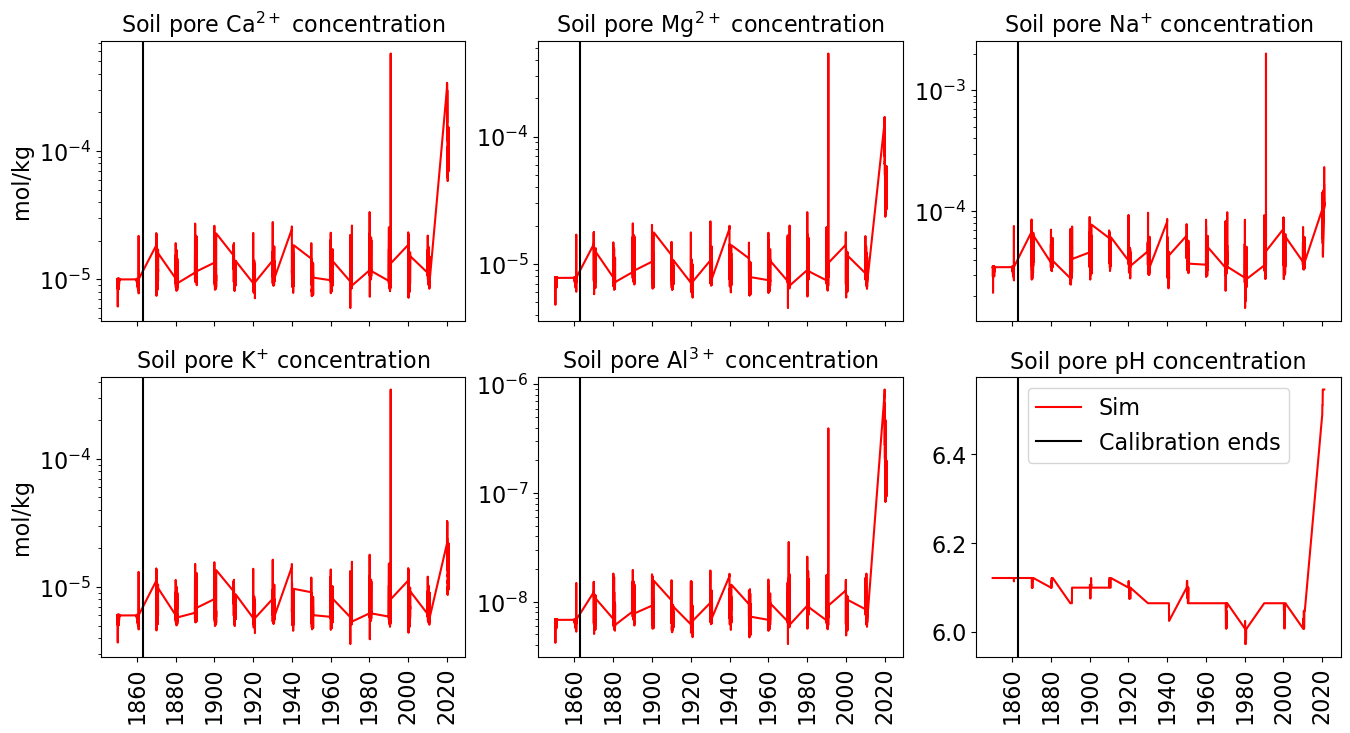

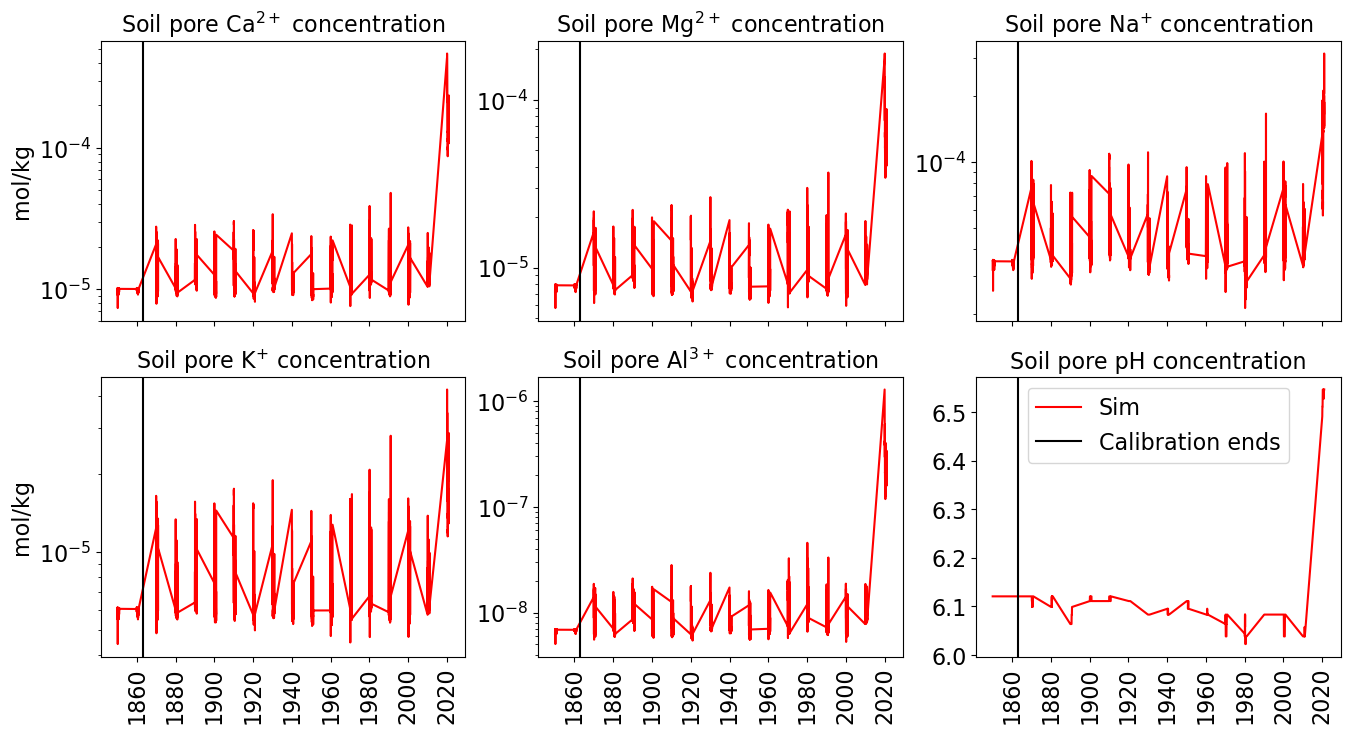

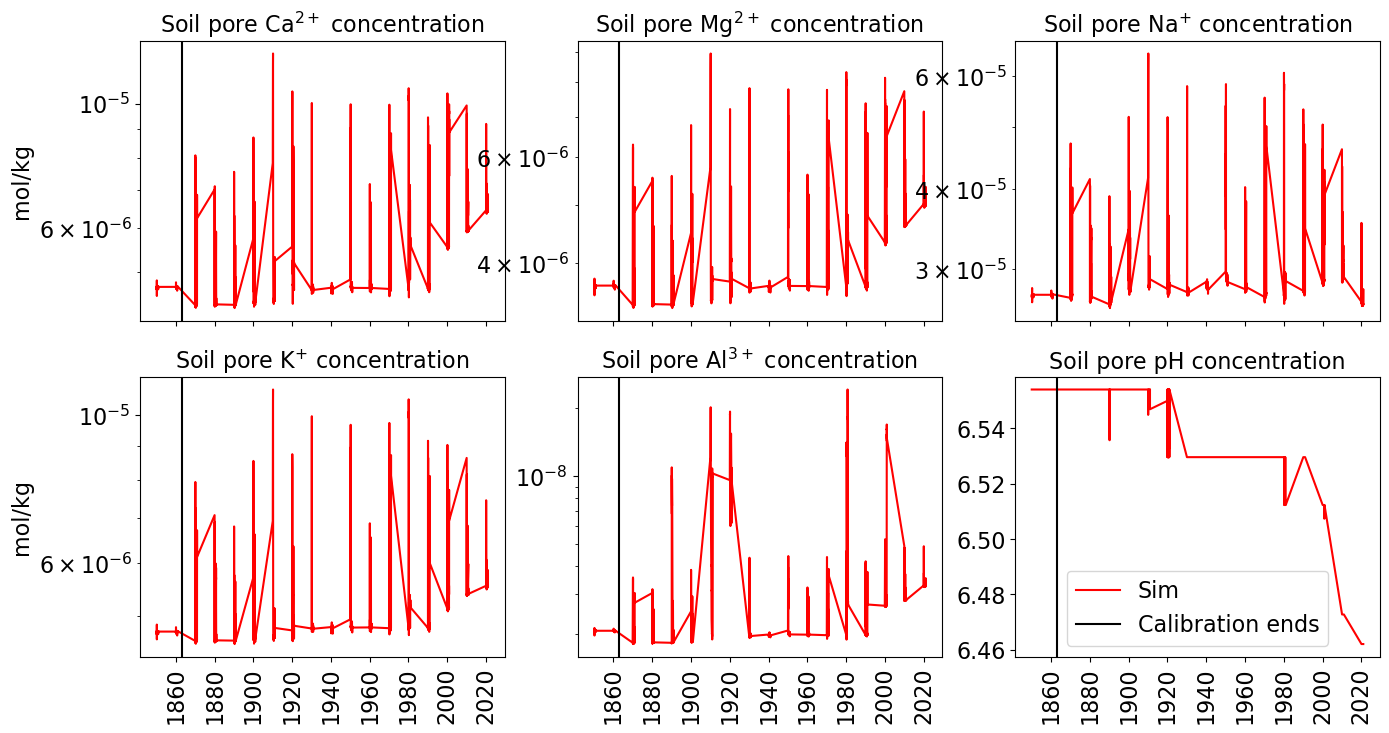

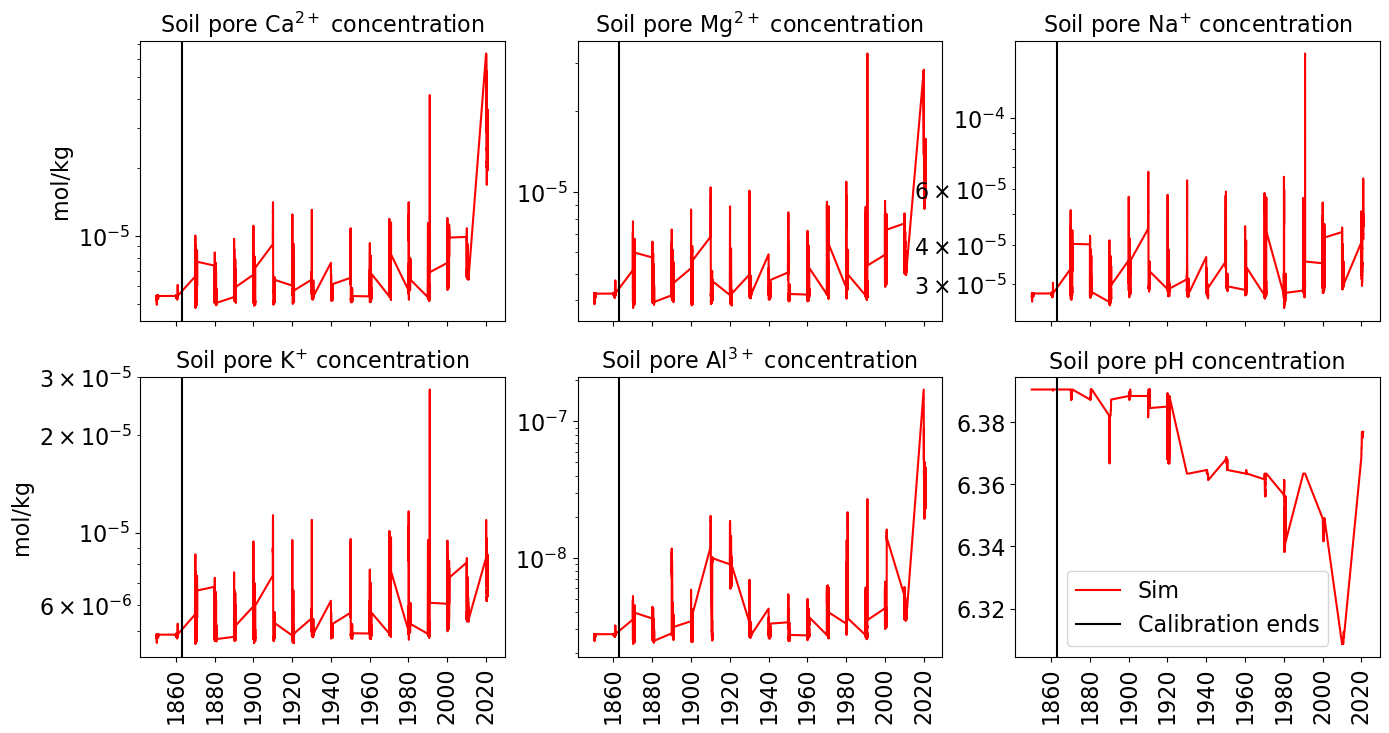

In [3]:
# Layerwise soil pore water cation concentration
# Oe: 0-2.5cm (lacks std in 2020)
# Oa: 2.5-7cm
# B: 20-60cm

# convert from g m-3 soil to mol/kg porewater
soil_pore_sim = {}
for i, (cation, mass_ca) in \
    enumerate(zip(['Ca2+','Mg2+','Na+','K+','Al3+'], 
                  [40, 24, 23, 29, 27])):
    soil_pore_sim[(cation, 'Oe')] = pd.Series( 
        (hr[f'cation_vr_{i+1}'][:,:2,0] * np.array([1.75, 2.5-1.75]).reshape(1,-1) * 1e-2 \
          / mass_ca / hr['SOILLIQ'][:,:2,0]).sum(axis = 1), 
        index = tvec)
    soil_pore_sim[(cation, 'Oa')] = pd.Series(
        (hr[f'cation_vr_{i+1}'][:,1:3,0] * np.array([4.51-2.5, 7-4.51]).reshape(1,-1) * 1e-2 \
          / mass_ca / hr['SOILLIQ'][:,1:3,0]).sum(axis = 1), 
        index = tvec)
    soil_pore_sim[(cation, 'B')] = pd.Series(
        (hr[f'cation_vr_{i+1}'][:,4:6,0] * np.array([28.91-20, 49.29-28.91]).reshape(1,-1) * 1e-2 \
          / mass_ca / hr['SOILLIQ'][:,4:6,0]).sum(axis = 1), 
        index = tvec)
soil_pore_sim[('pH', 'Oe')] = pd.Series( 
        (hr[f'soil_pH'][:,:2,0] * np.array([1.75, 2.5-1.75]).reshape(1,-1)).sum(axis = 1) / 2.5, 
        index = tvec)
soil_pore_sim[('pH', 'Oa')] = pd.Series( 
    (hr[f'soil_pH'][:,1:3,0] * np.array([4.51-2.5, 7-4.51]).reshape(1,-1)).sum(axis = 1) / (7-2.5), 
        index = tvec)
soil_pore_sim[('pH', 'B')] = pd.Series( 
    (hr[f'soil_pH'][:,4:6,0] * np.array([28.91-20, 49.29-28.91]).reshape(1,-1) # , 60-49.29
     ).sum(axis = 1) / (49.29-20), # (60-20), 
        index = tvec)
soil_pore_sim = pd.DataFrame(soil_pore_sim).stack()
soil_pore_sim.index = soil_pore_sim.index.reorder_levels([1, 0])
soil_pore_sim = soil_pore_sim.sort_index()

# Show 3-layer integrated modeled outcome too!!!
for layer in ['Oe', 'Oa', 'B', 'OaeB']:
    if layer == 'OaeB':
        sim = (soil_pore_sim.loc['Oe', :] * 0.025 + soil_pore_sim.loc['Oa', :] * 0.045 + 
               soil_pore_sim.loc['B', :] * 0.3929) / (0.4 + 0.025 + 0.045)
    else:
        sim = soil_pore_sim.loc[layer, :]

    fig, axes = plt.subplots(2, 3, figsize = (16, 8), sharex = True)
    for i, (obs_ca, sim_ca, name) in enumerate(
        zip(['Ca2+', 'Mg2+', 'Na+', 'K+', 'Alt', 'pH'],
            ['Ca2+','Mg2+','Na+','K+','Al3+', 'pH'], 
            ['Ca$^{2+}$', 'Mg$^{2+}$', 'Na$^{+}$', 'K$^{+}$', 'Al$^{3+}$', 'pH'])
    ):
        ax = axes.flat[i]
        ax.plot(sim[sim_ca].index, sim[sim_ca], '-r', label = 'Sim')

        ax.set_xlabel('')
        if np.mod(i, 3) == 0:
            ax.set_ylabel('mol/kg')
        if sim_ca != 'pH':
            ax.set_yscale('log')
        ax.set_title(f'Soil pore {name} concentration')
        plt.setp(ax.get_xticklabels(), rotation = 90)

        ax.axvline(pd.Timestamp(datestr), color = 'k', label = 'Calibration ends')

        #ax.set_xlim(sim[sim_ca].index[400], sim[sim_ca].index[-1])

    ax.legend(ncol = 1)

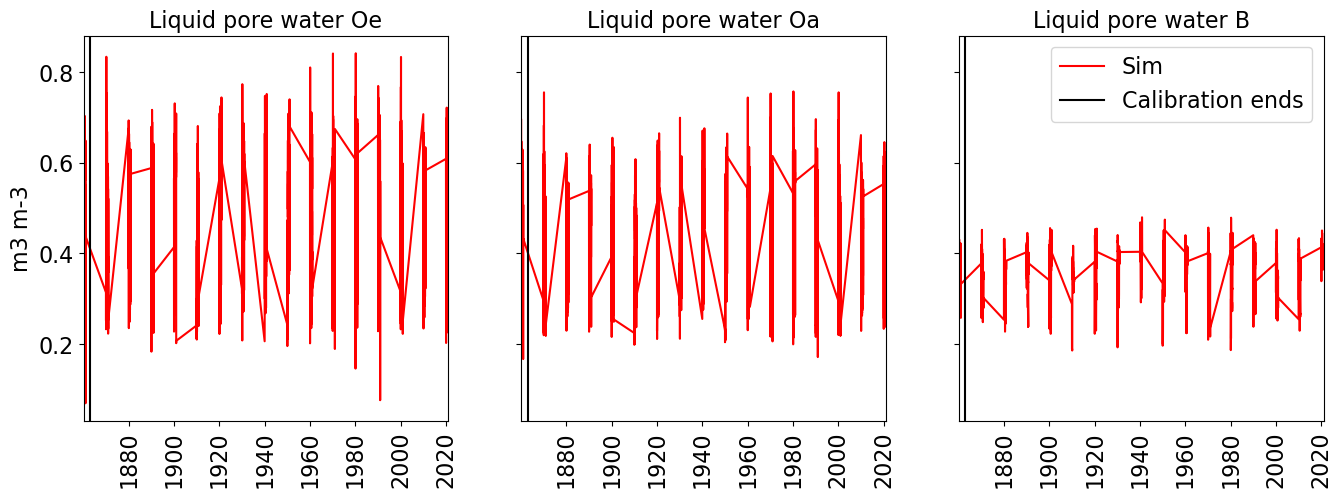

In [4]:
# Layerwise soil pore water content, liquid
# Oe: 0-2.5cm (lacks std in 2020)
# Oa: 2.5-7cm
# B: 20-60cm

# convert from kg m-2 soil to m3 m-3 soil
soil_pore_wat = {}
soil_pore_wat['Oe'] = pd.Series( hr['SOILLIQ'][:,:2,0].sum(axis=1) * 1e-3 / (2.5*0.01), index = tvec )
soil_pore_wat['Oa'] = pd.Series( hr['SOILLIQ'][:,1:3,0].sum(axis=1) * 1e-3 / ((7-2.5)*0.01), index = tvec )
soil_pore_wat['B'] = pd.Series( hr['SOILLIQ'][:,4:6,0].sum(axis=1) * 1e-3 / ((49.29-20)*0.01), index = tvec )

fig, axes = plt.subplots(1, 3, figsize = (16, 5), sharex = True, sharey = True)
for i, level in enumerate(['Oe','Oa','B']):
    ax = axes.flat[i]
    ax.plot(soil_pore_wat[level].index, soil_pore_wat[level], '-r', label = 'Sim')

    ax.set_xlabel('')
    if np.mod(i, 3) == 0:
        ax.set_ylabel('m3 m-3')
    ax.set_title(f'Liquid pore water {level}')
    plt.setp(ax.get_xticklabels(), rotation = 90)

    ax.axvline(pd.Timestamp(datestr), color = 'k', label = 'Calibration ends')

    ax.set_xlim(sim[sim_ca].index[400], sim[sim_ca].index[-1])

ax.legend(ncol = 1)

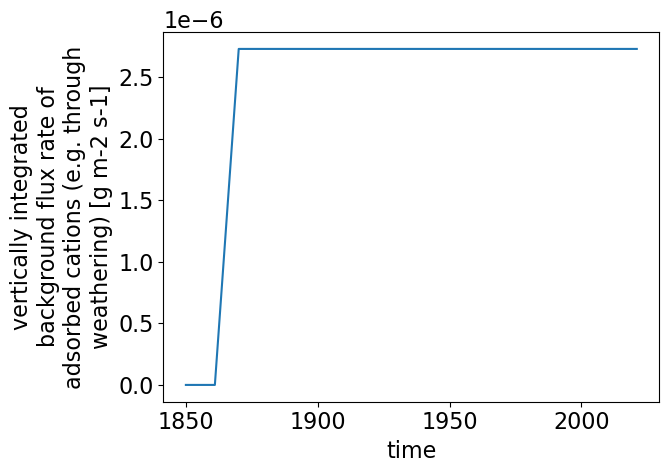

In [5]:
hr['background_cec'][:,0,0].plot()

/tmp/ipykernel_3480332/322059947.py:31: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  soil_cec_sim = pd.DataFrame(soil_cec_sim).stack()


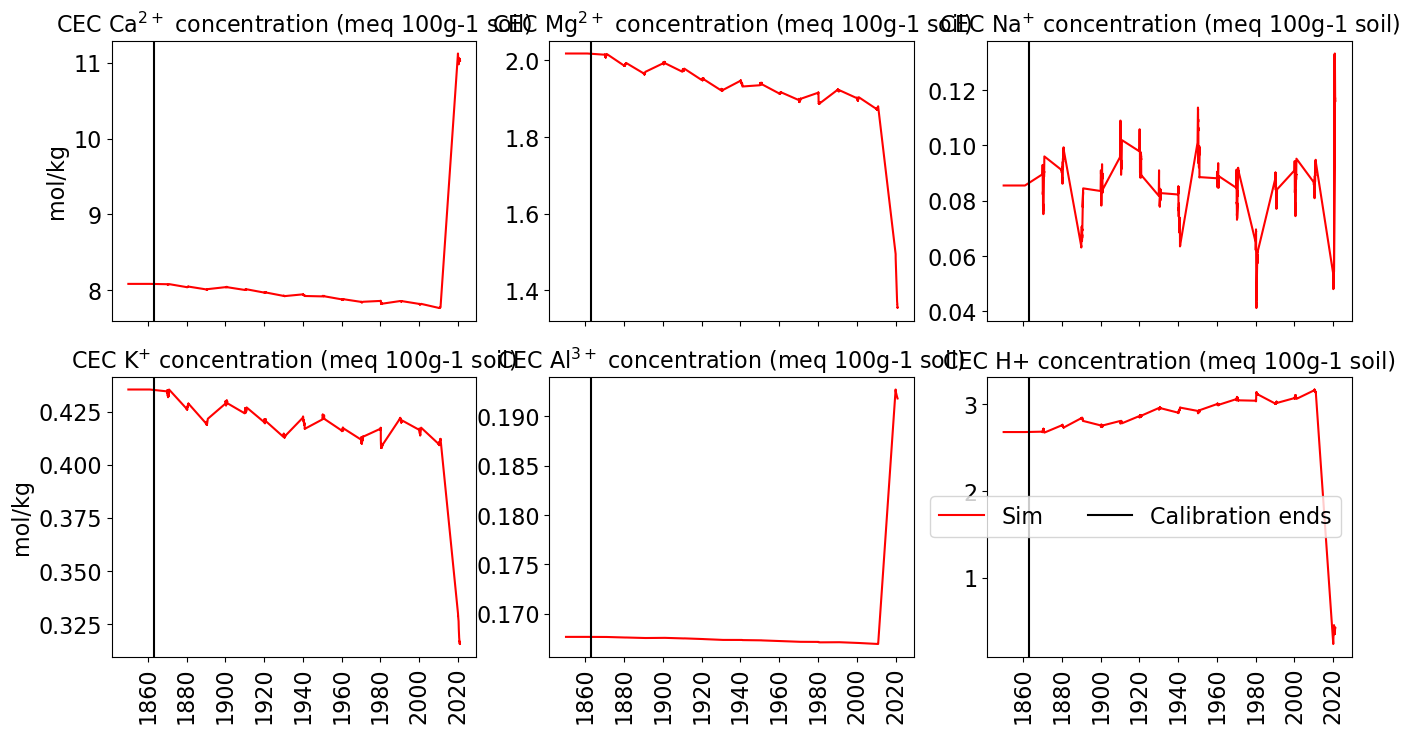

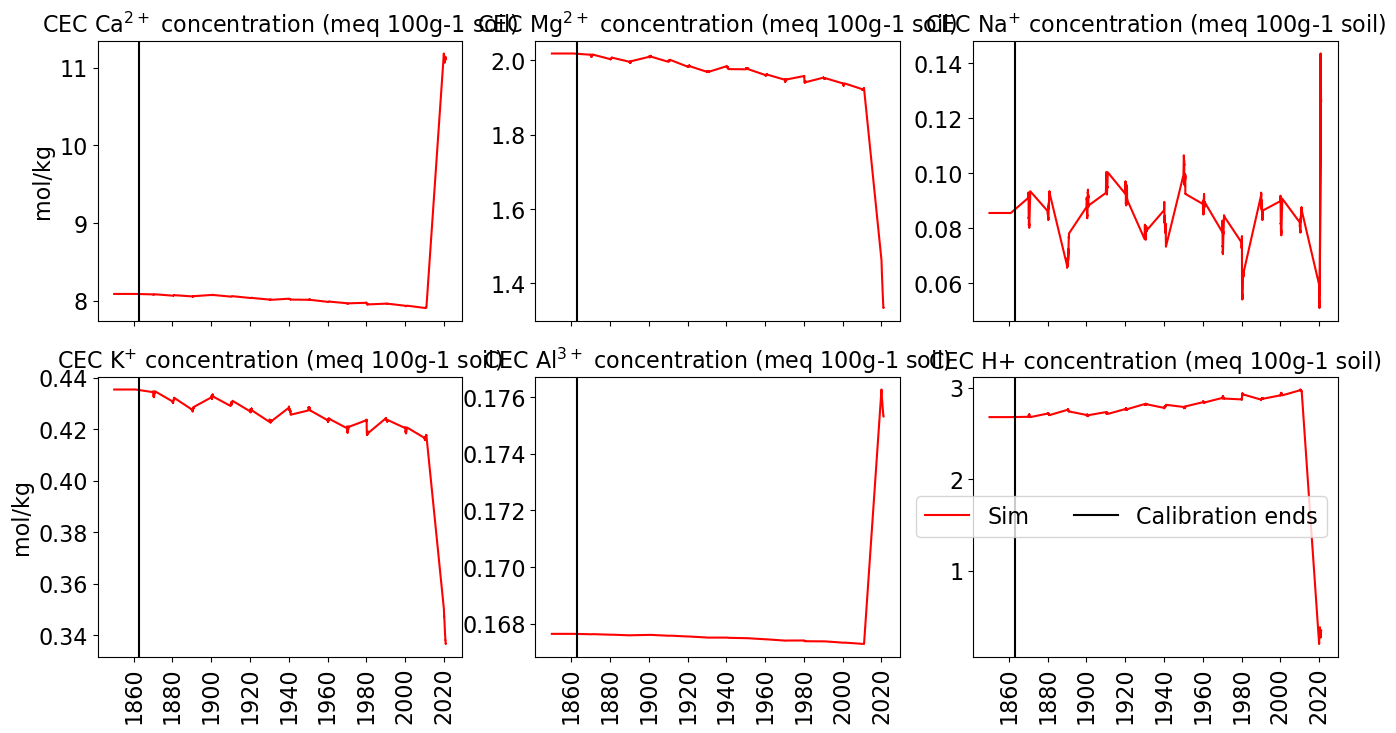

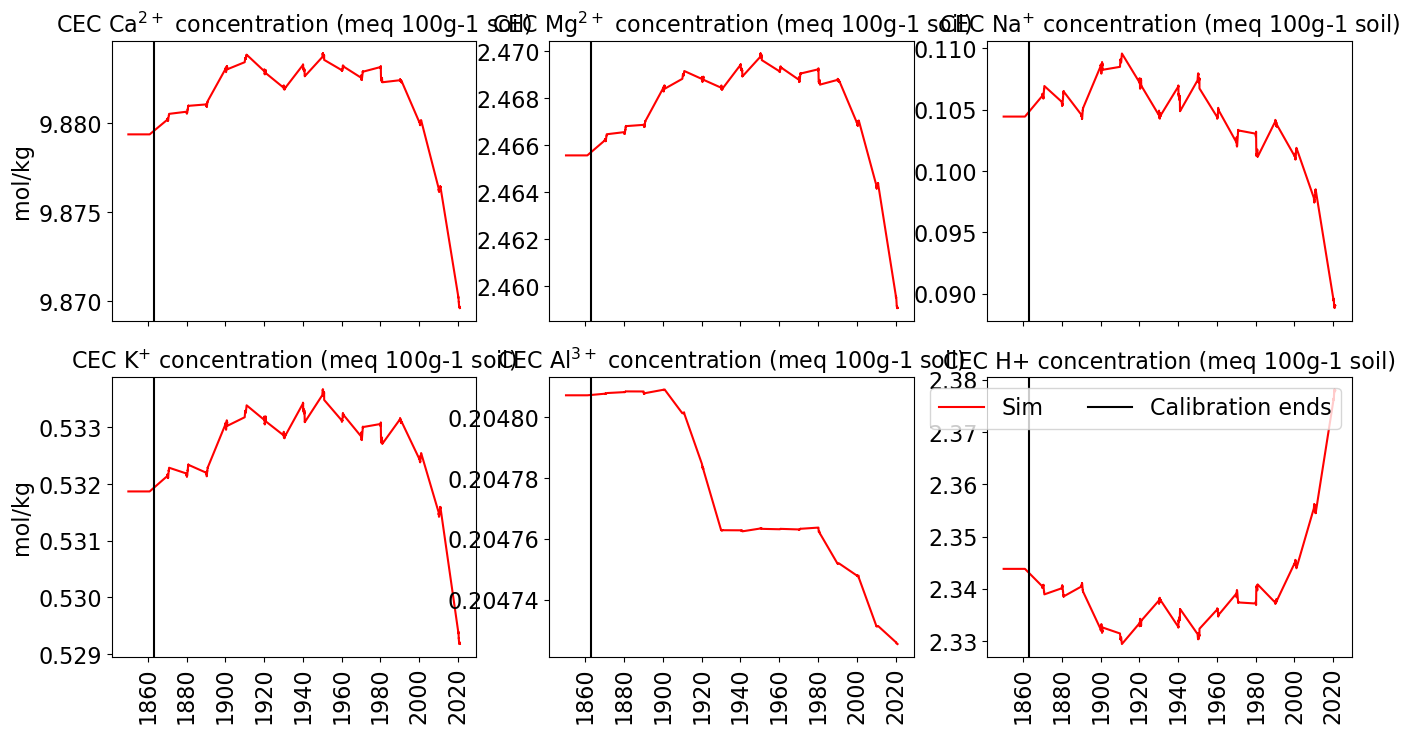

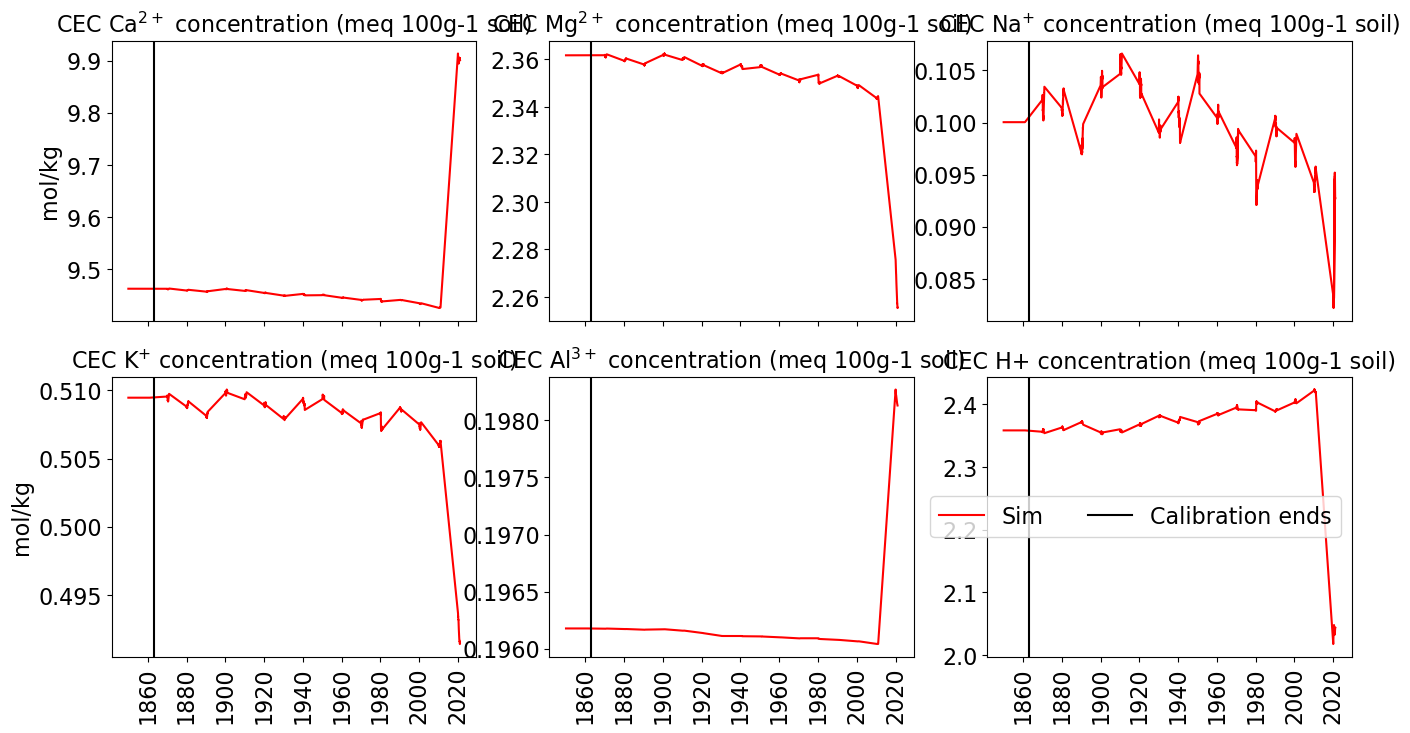

In [6]:
# Layerwise soil CEC cation concentration (meq 100g-1 soil)
soil_cec_sim = {}
for i, (cation, mass_ca, val_ca) in \
    enumerate(zip(['Ca2+','Mg2+','Na+','K+','Al3+'], 
                  [40, 24, 23, 29, 27], 
                  [2, 2, 1, 1, 3])):
    soil_cec_sim[(cation, 'Oe')] = pd.Series( 
        ((hr[f'cec_cation_vr_{i+1}'][:,:2,0] * val_ca * 100 / hr['bd_col'][:,:2,0] / mass_ca) *
          np.array([1.75, 2.5-1.75]).reshape(1,-1)).sum(axis = 1) / 2.5, 
        index = tvec)
    soil_cec_sim[(cation, 'Oa')] = pd.Series( 
        ((hr[f'cec_cation_vr_{i+1}'][:,1:3,0] * val_ca * 100 / hr['bd_col'][:,1:3,0] / mass_ca) *
          np.array([4.51-2.5, 7-4.51]).reshape(1,-1)).sum(axis = 1) / (7-2.5), 
        index = tvec)
    soil_cec_sim[(cation, 'B')] = pd.Series( 
        ((hr[f'cec_cation_vr_{i+1}'][:,4:6,0] * val_ca * 100 / hr['bd_col'][:,4:6,0] / mass_ca) *
          np.array([28.91-20, 49.29-28.91]).reshape(1,-1)).sum(axis = 1) / (49.29-20), #, 60-49.29, (60-20)
        index = tvec)
soil_cec_sim[('H+', 'Oe')] = pd.Series(
        ((hr[f'cec_proton_vr'][:,:2,0] * 100 / hr['bd_col'][:,:2,0]) *
         np.array([1.75, 2.5-1.75]).reshape(1,-1)).sum(axis = 1) / 2.5, 
        index = tvec)
soil_cec_sim[('H+', 'Oa')] = pd.Series(
        ((hr[f'cec_proton_vr'][:,1:3,0] * 100 / hr['bd_col'][:,1:3,0]) *
         np.array([4.51-2.5, 7-4.51]).reshape(1,-1)).sum(axis = 1) / (7-2.5),
        index = tvec)
soil_cec_sim[('H+', 'B')] = pd.Series( 
     (hr[f'cec_proton_vr'][:,4:6,0] * 100 / hr['bd_col'][:,4:6,0] * 
      np.array([28.91-20, 49.29-28.91]).reshape(1,-1)).sum(axis = 1) / (49.29-20), # (60-20), 
     index = tvec)
soil_cec_sim = pd.DataFrame(soil_cec_sim).stack()
soil_cec_sim.index = soil_cec_sim.index.reorder_levels([1, 0])
soil_cec_sim = soil_cec_sim.sort_index()

# Show 3-layer integrated modeled outcome too!!!
for layer in ['Oe', 'Oa', 'B', 'OaeB']:
    if layer == 'OaeB':
        sim = (soil_cec_sim.loc['Oe', :] * 0.025 + soil_cec_sim.loc['Oa', :] * 0.045 + 
               soil_cec_sim.loc['B', :] * 0.3929) / (0.4 + 0.025 + 0.045)
    else:
        sim = soil_cec_sim.loc[layer, :]

    fig, axes = plt.subplots(2, 3, figsize = (16, 8), sharex = True)
    for i, (obs_ca, sim_ca, name) in enumerate(
        zip(['Ca2+', 'Mg2+', 'Na+', 'K+', 'Alt', 'H+'],
            ['Ca2+','Mg2+','Na+','K+','Al3+', 'H+'], 
            ['Ca$^{2+}$', 'Mg$^{2+}$', 'Na$^{+}$', 'K$^{+}$', 'Al$^{3+}$', 'H+'])
    ):
        ax = axes.flat[i]
        ax.plot(sim[sim_ca].index, sim[sim_ca], '-r', label = 'Sim')

        ax.set_xlabel('')
        if np.mod(i, 3) == 0:
            ax.set_ylabel('mol/kg')

        ax.set_title(f'CEC {name} concentration (meq 100g-1 soil)')
        plt.setp(ax.get_xticklabels(), rotation = 90)

        ax.axvline(pd.Timestamp(datestr), color = 'k', label = 'Calibration ends')

        #ax.set_xlim(sim[sim_ca].index[400], sim[sim_ca].index[-1])
        #ax.set_ylim([0,15])

    ax.legend(ncol = 2)

In [14]:
soil_cec_sim.sum(axis = 1).unstack()

,1850-01-01,1850-01-02,1850-01-03,1850-01-04,1850-01-05,1850-01-06,1850-01-07,1850-01-08,1850-01-09,1850-01-10,...,2020-12-22,2020-12-23,2020-12-24,2020-12-25,2020-12-26,2020-12-27,2020-12-28,2020-12-29,2020-12-30,2020-12-31
B,15.529872,15.529872,15.529872,15.529872,15.529872,15.529872,15.529872,15.529872,15.529872,15.529872,...,15.529584,15.529585,15.529585,15.529584,15.529585,15.529584,15.529584,15.529585,15.529583,15.529584
Oa,13.471985,13.471985,13.471985,13.471985,13.471985,13.471985,13.471985,13.471985,13.471985,13.471985,...,13.428427,13.428426,13.428423,13.428412,13.428414,13.428417,13.428421,13.428423,13.428425,13.428429
Oe,13.471986,13.471986,13.471986,13.471986,13.471986,13.471986,13.471986,13.471986,13.471986,13.471986,...,13.423647,13.423648,13.423649,13.423635,13.423641,13.423647,13.423652,13.423652,13.423659,13.423663


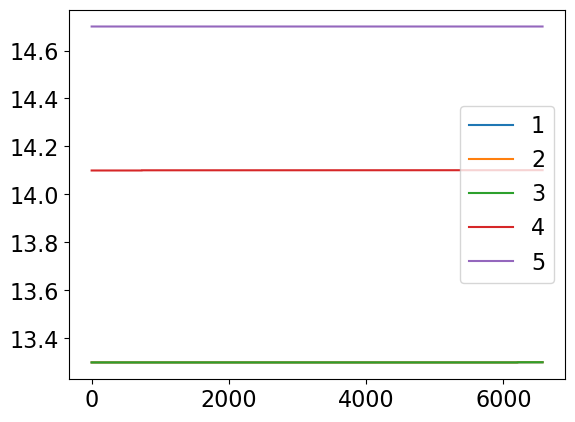

In [19]:
plt.plot(hr['cect_dyn'][:, :5, 0].values)
plt.legend(['1','2','3','4','5'])

/tmp/ipykernel_3480332/3389762389.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  temp = soil_cec_sim.reorder_levels([1,0], axis = 0).unstack().resample('1Y').mean()
/tmp/ipykernel_3480332/3389762389.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  temp = temp.stack().reorder_levels([1,0]).sort_index()


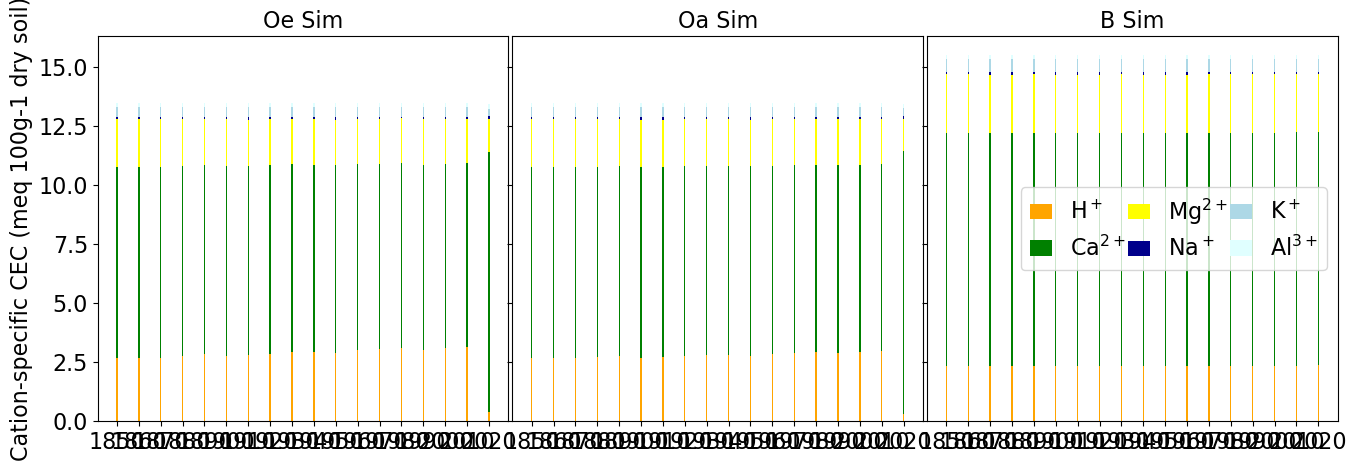

In [8]:
## Convert to beta values (fraction)
temp = soil_cec_sim.reorder_levels([1,0], axis = 0).unstack().resample('1Y').mean()
temp.index = temp.index.year
temp = temp.stack().reorder_levels([1,0]).sort_index()
cec_sim = temp # / temp.sum(axis = 1).values.reshape(-1, 1)
# re-align the simulation's cation rank
cec_sim = cec_sim.loc[:, ['H+','Ca2+','Mg2+','Na+','K+','Al3+']]


color_list = ['#FFA500', '#008000', '#FFFF00', '#00008B', '#ADD8E6', '#E0FFFF']
name_list = ['H$^+$', 'Ca$^{2+}$', 'Mg$^{2+}$', 'Na$^+$', 'K$^+$', 'Al$^{3+}$']
handles = [Patch(facecolor=color, label=label) for color, label in zip(color_list, name_list)]

def plot_bar(df, ax):
    for j, x in enumerate(df.index):
        bottom = 0  # Starting bottom for stacking
        for col, color in zip(df.columns, color_list):
            value = df.loc[x, col]
            ax.bar(x, value, bottom=bottom, color=color, width=0.6)
            bottom += value

fig, axes = plt.subplots(1, 3, figsize = (16, 5), sharex = True, sharey = True)
fig.subplots_adjust(hspace = 0.1, wspace = 0.01)
for i, horizon in enumerate(['Oe', 'Oa', 'B']):

    plot_bar( cec_sim.loc[horizon], axes.flat[i] )

    # Place the legend outside the plot area (to the right)
    if i == 2:
        axes[i].legend(handles=handles, ncol = 3, handlelength = 1, 
                         columnspacing = 0.1)

    if i == 0:
        axes[i].set_ylabel(f'Cation-specific CEC (meq 100g-1 dry soil)')
    axes[i].set_xticks(cec_sim.loc[horizon].index)
    axes[i].set_title(f'{horizon} Sim')

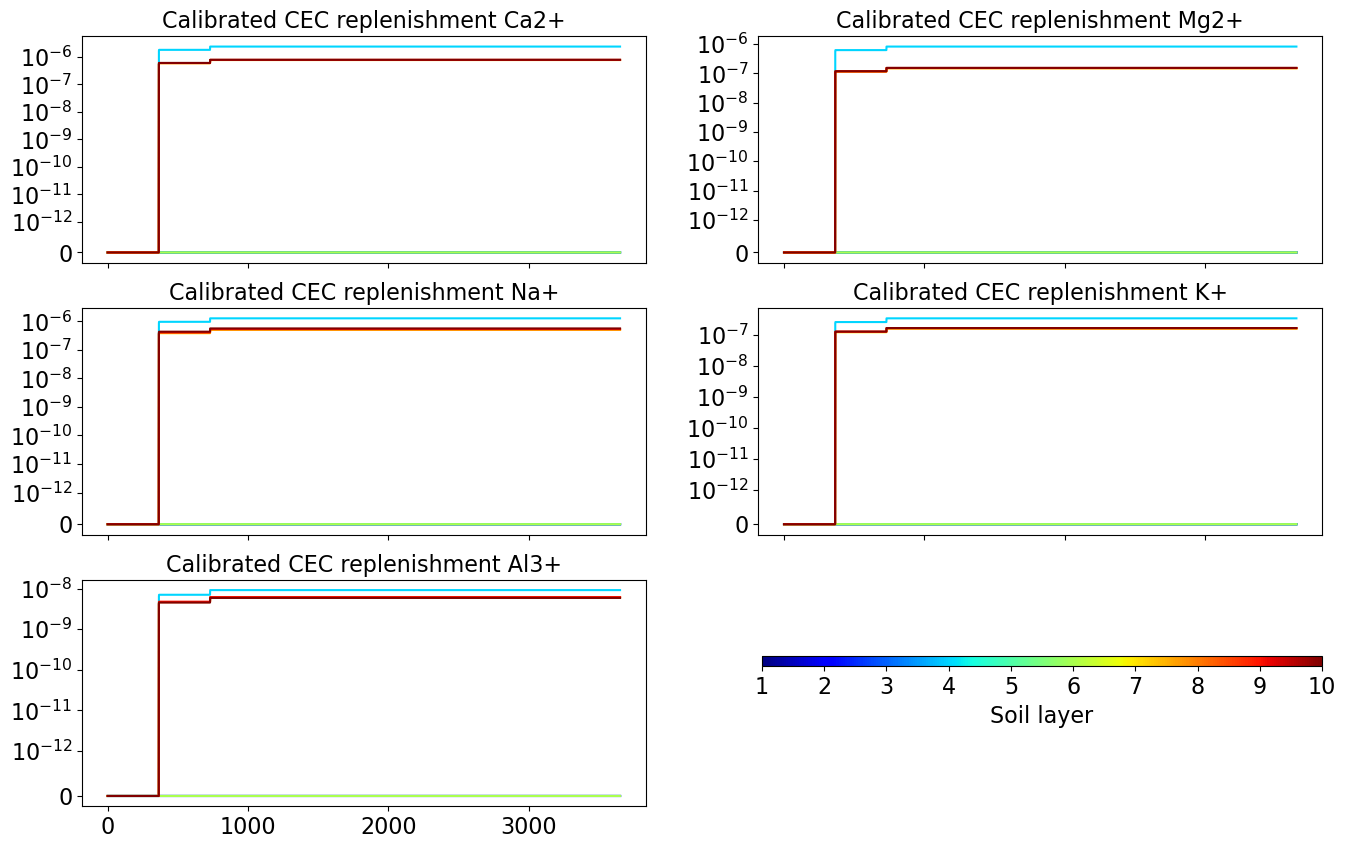

In [9]:
# Plot the replenishment rate for CEC
if site == 'HBR':
    nlevsoi = 7
else:
    nlevsoi = 10

cmap = plt.cm.jet
norm = plt.Normalize(vmin=1, vmax=nlevsoi)
colors = cmap(norm(np.arange(1, nlevsoi+1)))

fig, axes = plt.subplots(3, 2, sharex = True, sharey = False, figsize = (16, 10))
for icat, cation in enumerate(['Ca2+','Mg2+','Na+','K+','Al3+']):
    ax = axes.flat[icat]

    for layer in range(nlevsoi):
        ax.plot(-hr[f'annavg_cec_delta_vr_{icat+1}'][:(365*10), layer, 0].values, 
                label = 'calibrate', color = colors[layer])

    ax.set_title(f'Calibrated CEC replenishment {cation}')
    ax.set_yscale('symlog', linthresh = 1e-12)
axes.flat[-1].axis('off')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # dummy mappable
cax = fig.add_axes([0.55, 0.25, 0.35, 0.01])
cbar = fig.colorbar(sm, cax=cax, ticks=np.arange(1, 12), orientation = 'horizontal')
cbar.set_label('Soil layer')
cbar.set_ticklabels(np.arange(1, 12))

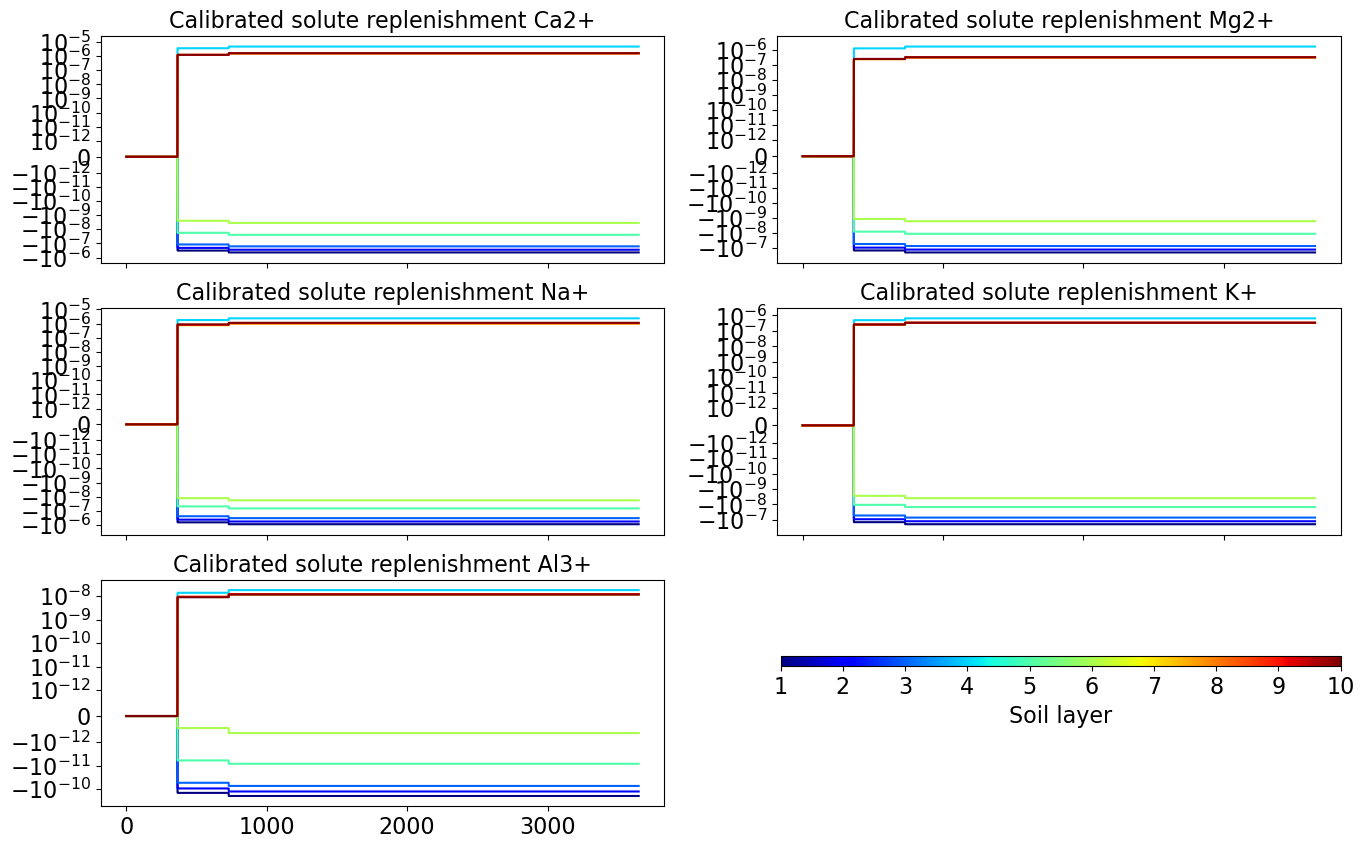

In [10]:
# Plot the replenishment rate for the solution phase
if site == 'HBR':
    nlevsoi = 7
else:
    nlevsoi = 10

cmap = plt.cm.jet
norm = plt.Normalize(vmin=1, vmax=nlevsoi)
colors = cmap(norm(np.arange(1, nlevsoi+1)))

fig, axes = plt.subplots(3, 2, sharex = True, sharey = False, figsize = (16, 10))
for icat, cation in enumerate(['Ca2+','Mg2+','Na+','K+','Al3+']):
    ax = axes.flat[icat]

    for layer in range(nlevsoi):
        temp = hr[f'annavg_cec_delta_vr_{icat+1}'][:(365*10), layer, 0].values - \
               hr[f'annavg_tot_delta_vr_{icat+1}'][:(365*10), layer, 0].values

        ax.plot(-temp, label = 'calibrate', color = colors[layer])

    ax.set_title(f'Calibrated solute replenishment {cation}')
    ax.set_yscale('symlog', linthresh = 1e-12)
axes.flat[-1].axis('off')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # dummy mappable
cax = fig.add_axes([0.55, 0.25, 0.35, 0.01])
cbar = fig.colorbar(sm, cax=cax, ticks=np.arange(1, 12), orientation = 'horizontal')
cbar.set_label('Soil layer')
cbar.set_ticklabels(np.arange(1, 12))

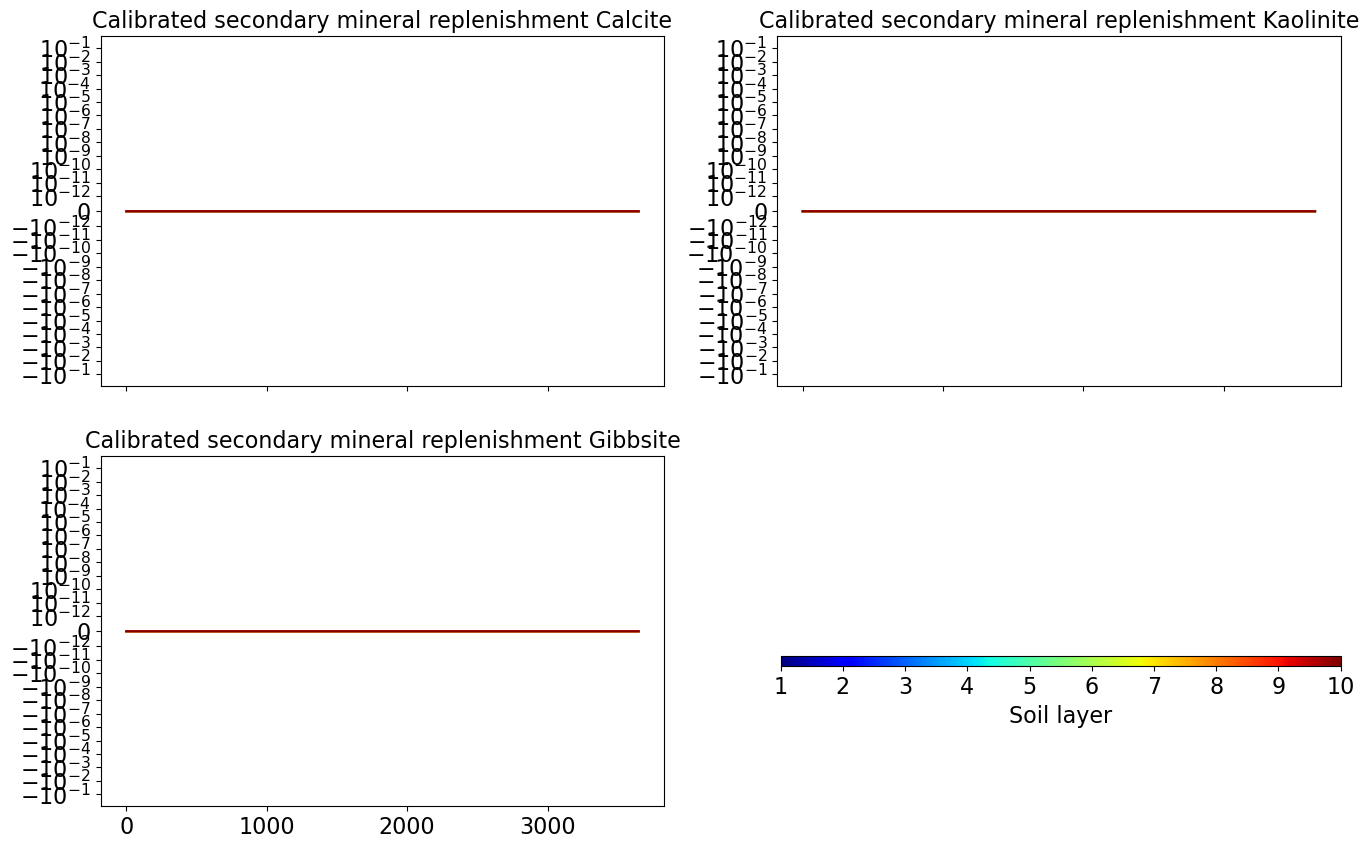

In [11]:
# Plot the replenishment rate for the secondary minerals
if site == 'HBR':
    nlevsoi = 7
else:
    nlevsoi = 10

cmap = plt.cm.jet
norm = plt.Normalize(vmin=1, vmax=nlevsoi)
colors = cmap(norm(np.arange(1, nlevsoi+1)))

fig, axes = plt.subplots(2, 2, sharex = True, sharey = False, figsize = (16, 10))
for isec, minsec in enumerate(['Calcite','Kaolinite','Gibbsite']):
    ax = axes.flat[isec]

    for layer in range(nlevsoi):
        temp = hr[f'annavg_minsecs_delta_vr_{isec+1}'][:(365*10), layer, 0].values

        ax.plot(-temp, label = 'calibrate', color = colors[layer])

    ax.set_title(f'Calibrated secondary mineral replenishment {minsec}')
    ax.set_yscale('symlog', linthresh = 1e-12)
axes.flat[-1].axis('off')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # dummy mappable
cax = fig.add_axes([0.55, 0.25, 0.35, 0.01])
cbar = fig.colorbar(sm, cax=cax, ticks=np.arange(1, 12), orientation = 'horizontal')
cbar.set_label('Soil layer')
cbar.set_ticklabels(np.arange(1, 12))

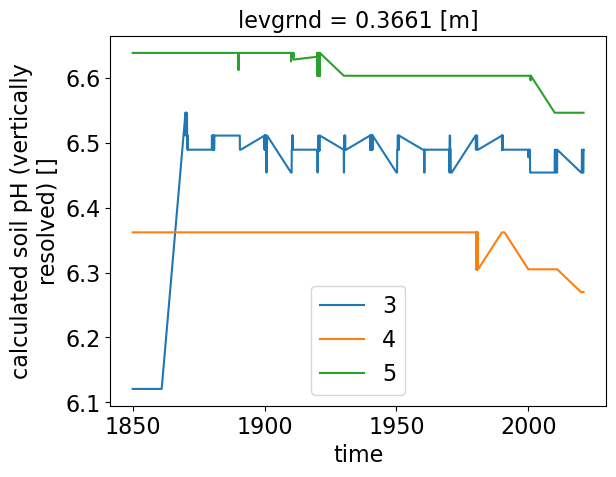

In [12]:
for d in [3,4,5]:
    hr['soil_pH'][:, d, 0].plot(label = d)
plt.legend()